
# Introduction to Data Science - Assignment 3
**Author:** Yahav Alkoby
**Institution:** HIT - Holon Institute of Technology
**Dataset:** Google Smartphone Decimeter Challenge (`device_gnss_p4xl_train.csv`)
## Table of Contents:
1. **Dataset Selection & Setup**
   * 1.1 Data Source Description
   * 1.2 Environment Setup & Data Loading
2. **Meta-Analysis**
   * 2.1 File Analysis & Data Structure
3. **Data Quality and Completeness**
   * 3.1 Null Values and Data Types
   * 3.2 Data Duplicates
   * 3.3 Impossible Values & Placeholders
   * 3.4 Cardinality
4. **Univariate Analysis & Outlier Detection**
5. **Bivariate Analysis: Correlations**
6. **Graphs and Visualizations**
7. **Dimensionality Reduction (PCA)**
8. **Clustering Analysis**
9. **Multi-Dimensional Anomaly Detection**
10. **Comparison Section & Dashboard**

# 1.1 Data Selecion
* Data Source:
Raw Global Navigation Satellite System (GNSS) telemetry logs derived from Android smartphones participating in the Google Smartphone Decimeter Challenge datasets (specifically device_gnss_train_p4xl.csv). The file contains tabular low-level measurement data such as satellite IDs (Svid), constellation identifiers (ConstellationType), carrier-to-noise density ratios (Cn0DbHz), satellite elevation and azimuth angles, and pseudorange measurements.

* Purpose of Collection:
The primary objective of collecting these raw telemetry logs is to provide researchers, data scientists, and navigation engineers with real-world, highly challenging positioning data. This enables the development, benchmarking, and machine learning optimization of advanced localization algorithms aimed at achieving sub-meter smartphone positioning accuracy, particularly in complex urban environments where traditional GPS signals degrade.

* Collecting Entity:
Google, in collaboration with academic institutions and industrial positioning partners, as part of open-data challenges designed to advance smartphone navigation and GNSS error-correction research.

* Domain Knowledge Linkage:
From an electrical engineering and signal processing perspective, smartphones utilize low-cost, linearly polarized patch antennas rather than professional geodetic survey receivers. Consequently, the data is physically constrained by structural noise:

    * Multipath Interference: Signals interacting with urban structures (buildings, asphalt) reflect and bounce, causing false pseudorange measurements.

    * Signal Attenuation: Satellites lower on the horizon suffer from atmospheric and structural degradation, directly lowering the Carrier-to-Noise ratio (Cn0DbHz).

    Understanding these physical limitations allows us to link telemetry metrics directly to positioning errors.

* Analytical Insight (Missing Information Note):
While the telemetry logs provide granular physical measurements per epoch, they lack explicit contextual metadata regarding the exact surrounding urban geography (e.g., building heights, exact street canyon widths) or environmental weather conditions during individual recordings. This absence of rich environmental metadata is itself a key insight: it forces data scientists to rely entirely on statistical feature engineering (such as isolating line-of-sight signals via elevation and signal thresholds) to infer environmental hostility.


---
## 1.2 Environment Setup
We begin by importing the core data science libraries. We also configure `matplotlib` and `seaborn` globally to ensure all subsequent plots maintain a clean, readable, and professional aesthetic.



In [58]:
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

# Configure visualization settings globally
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
warnings.filterwarnings("ignore")

print("Environment setup completed successfully.")


Environment setup completed successfully.



---
## 2. Meta-Analysis
In this section, we load the GNSS telemetry data into a Pandas DataFrame. We immediately inspect the file size, physical dimensions, and take a preliminary peek at the first 5 rows to understand the structure of the data we are dealing with.
    


In [59]:
file_path = "device_gnss_train_p4xl.csv"  # Ensure this file is in your working directory

try:
    file_size_mb = os.path.getsize(file_path) / (1024 * 1024)
    df = pd.read_csv(file_path)

    print(f"File Name: {os.path.basename(file_path)}")
    print(f"File Size: {file_size_mb:.2f} MB")
    print(f"Dimensions: {df.shape[0]:,} rows x {df.shape[1]} columns")
    print("The Purpose of the dataset is to explore gnss logs from devices")

    display(df.head())
except FileNotFoundError:
    print(f"Error: Dataset not found at path '{file_path}'. Please verify the file location.")


File Name: device_gnss_train_p4xl.csv
File Size: 30.55 MB
Dimensions: 48,481 rows x 58 columns
The Purpose of the dataset is to explore gnss logs from devices


,MessageType,utcTimeMillis,TimeNanos,LeapSecond,TimeUncertaintyNanos,FullBiasNanos,BiasNanos,BiasUncertaintyNanos,DriftNanosPerSecond,DriftUncertaintyNanosPerSecond,...,SvVelocityYEcefMetersPerSecond,SvVelocityZEcefMetersPerSecond,SvClockBiasMeters,SvClockDriftMetersPerSecond,IsrbMeters,IonosphericDelayMeters,TroposphericDelayMeters,WlsPositionXEcefMeters,WlsPositionYEcefMeters,WlsPositionZEcefMeters
0,Raw,1593045251447,22822513000000,18,NaN,-1277057646934970240,0.366306,21.479316,11.443134,11.805236,...,45.224788,2921.185153,-114240.988444,-0.002747,0.0,2.990955,3.331083,-2.692779e+06,-4.297235e+06,3.855231e+06
1,Raw,1593045251447,22822513000000,18,NaN,-1277057646934970240,0.366306,21.479316,11.443134,11.805236,...,2683.345352,728.348308,6344.270928,0.000551,0.0,4.233148,9.595780,-2.692779e+06,-4.297235e+06,3.855231e+06
2,Raw,1593045251447,22822513000000,18,NaN,-1277057646934970240,0.366306,21.479316,11.443134,11.805236,...,2112.145384,1639.422495,-66543.908262,-0.000458,0.0,3.189828,4.111674,-2.692779e+06,-4.297235e+06,3.855231e+06
3,Raw,1593045251447,22822513000000,18,NaN,-1277057646934970240,0.366306,21.479316,11.443134,11.805236,...,-728.869571,-2495.102357,-52349.704391,-0.001108,0.0,4.307071,5.539308,-2.692779e+06,-4.297235e+06,3.855231e+06
4,Raw,1593045251447,22822513000000,18,NaN,-1277057646934970240,0.366306,21.479316,11.443134,11.805236,...,-1692.724867,-1274.062821,68762.683069,0.003014,0.0,2.381465,2.830852,-2.692779e+06,-4.297235e+06,3.855231e+06



### 3. Data structure




In [60]:
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}\n")

df.info()

Number of Rows: 48481
Number of Columns: 58

<class 'pandas.DataFrame'>
RangeIndex: 48481 entries, 0 to 48480
Data columns (total 58 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   MessageType                                48481 non-null  str    
 1   utcTimeMillis                              48481 non-null  int64  
 2   TimeNanos                                  48481 non-null  int64  
 3   LeapSecond                                 48481 non-null  int64  
 4   TimeUncertaintyNanos                       0 non-null      float64
 5   FullBiasNanos                              48481 non-null  int64  
 6   BiasNanos                                  48481 non-null  float64
 7   BiasUncertaintyNanos                       48481 non-null  float64
 8   DriftNanosPerSecond                        48481 non-null  float64
 9   DriftUncertaintyNanosPerSecond             48481 non-null  f

Each row contains raw GNSS measurements, derived values, and a baseline estimated location. This baseline was computed using correctedPrM and the satellite positions, using a standard Weighted Least Squares (WLS) solver, with the phone's position (x, y, z), clock bias (t), and isrbM for each unique signal type as states for each epoch.

* **MessageType**: "Raw", the prefix of sentence.
* **utcTimeMillis**: Milliseconds since UTC epoch (1970/1/1), converted from GnssClock.
* **TimeNanos**: The GNSS receiver internal hardware clock value in nanoseconds.
* **LeapSecond**: The leap second associated with the clock's time.
* **FullBiasNanos**: The difference between hardware clock (getTimeNanos()) inside GPS receiver and the true GPS time since 0000Z, January 6, 1980, in nanoseconds.
* **BiasNanos**: The clock's sub-nanosecond bias.
* **BiasUncertaintyNanos**: The clock's bias uncertainty (1-sigma) in nanoseconds.
* **DriftNanosPerSecond**: The clock's drift in nanoseconds per second.
* **DriftUncertaintyNanosPerSecond**: The clock's drift uncertainty (1-sigma) in nanoseconds per second.
* **HardwareClockDiscontinuityCount**: Count of hardware clock discontinuities.
* **Svid**: The satellite ID.
* **TimeOffsetNanos**: The time offset at which the measurement was taken in nanoseconds.
* **State**: Integer signifying sync state of the satellite. Each bit in the integer attributes to a particular state information of the measurement.
* **ReceivedSvTimeNanos**: The received GNSS satellite time, at the measurement time, in nanoseconds.
* **ReceivedSvTimeUncertaintyNanos**: The error estimate (1-sigma) for the received GNSS time, in nanoseconds.
* **Cn0DbHz**: The carrier-to-noise density in dB-Hz.
* **PseudorangeRateMetersPerSecond**: The pseudorange rate at the timestamp in m/s.
* **PseudorangeRateUncertaintyMetersPerSecond**: The pseudorange's rate uncertainty (1-sigma) in m/s.
* **AccumulatedDeltaRangeState**: This indicates the state of the 'Accumulated Delta Range' measurement. Each bit in the integer attributes to state of the measurement. See the metadata/accumulated_delta_range_state_bit_map.json file for the mapping between bits and states.
* **AccumulatedDeltaRangeMeters**: The accumulated delta range since the last channel reset, in meters.
* **AccumulatedDeltaRangeUncertaintyMeters**: The accumulated delta range's uncertainty (1-sigma) in meters.
* **CarrierFrequencyHz**: The carrier frequency of the tracked signal.
* **MultipathIndicator**: A value indicating the 'multipath' state of the event.
* **ConstellationType**: GNSS constellation type.
* **CodeType**: The GNSS measurement's code type. Only available in recent logs.
* **ChipsetElapsedRealtimeNanos**: The elapsed real-time of this clock since system boot, in nanoseconds. Only available in recent logs.
* **ArrivalTimeNanosSinceGpsEpoch**: An integer number of nanoseconds since the GPS epoch (1980/1/6 midnight UTC). Its value equals round((Raw::TimeNanos - Raw::FullBiasNanos), for each unique epoch described in the Raw sentences.
* **RawPseudorangeMeters**: Raw pseudorange in meters. It is the product between the speed of light and the time difference from the signal transmission time (receivedSvTimeInGpsNanos) to the signal arrival time (Raw::TimeNanos - Raw::FullBiasNanos - Raw::BiasNanos). Its uncertainty can be approximated by the product between the speed of light and the ReceivedSvTimeUncertaintyNanos.
* **SignalType**: The GNSS signal type is a combination of the constellation name and the frequency band.
* **ReceivedSvTimeNanosSinceGpsEpoch**: The signal transmission time received by the chipset, in the numbers of nanoseconds since the GPS epoch. Converted from ReceivedSvTimeNanos, this derived value is in a unified time scale for all constellations, while ReceivedSvTimeNanos refers to the time of day for GLONASS and the time of week for non-GLONASS constellations.
* **SvPosition[X/Y/Z]EcefMeters**: The satellite position (meters) in an ECEF coordinate.
* **Sv[Elevation/Azimuth]Degrees**: The elevation and azimuth in degrees of the satellite. They are computed using the WLS estimated user position.
* **SvVelocity[X/Y/Z]EcefMetersPerSecond**: The satellite velocity (meters per second) in an ECEF coordinate.
* **SvClockBiasMeters**: The satellite time correction combined with the satellite hardware delay in meters at the signal transmission time (receivedSvTimeInGpsNanos).
* **SvClockDriftMetersPerSecond**: The satellite clock drift in meters per second at the signal transmission time (receivedSvTimeInGpsNanos).
* **IsrbMeters**: The Inter-Signal Range Bias (ISRB) in meters from a non-GPS-L1 signal to GPS-L1 signals.
* **IonosphericDelayMeters**: The ionospheric delay in meters, estimated with the Klobuchar model.
* **TroposphericDelayMeters**: The tropospheric delay in meters, estimated with the EGNOS model by Nigel Penna, Alan Dodson and W. Chen (2001).
* **WlsPosition[X/Y/Z]EcefMeters**: User positions in ECEF estimated by a Weighted-Least-Square (WLS) solver.


### 3.1 Null Values and Data Types
A critical first step in EDA is understanding data completeness. Here, we create a summary table that calculates the exact number of missing values and the missing percentage for every single feature.
    


In [61]:
# Generate a metadata dataframe
meta_df = pd.DataFrame({
    "Data_Type": df.dtypes,
    "Non_Null_Count": df.notnull().sum(),
    "Null_Count": df.isnull().sum(),
    "Null_Percentage": (df.isnull().sum() / len(df)) * 100,
    "Unique_Values": df.nunique()
})

# Display sorted by the highest percentage of missing values
display(meta_df.sort_values(by="Null_Percentage", ascending=False))


,Data_Type,Non_Null_Count,Null_Count,Null_Percentage,Unique_Values
TimeUncertaintyNanos,float64,0,48481,100.000000,0
CarrierPhaseUncertainty,float64,0,48481,100.000000,0
CarrierCycles,float64,0,48481,100.000000,0
CarrierPhase,float64,0,48481,100.000000,0
SatelliteInterSignalBiasNanos,float64,0,48481,100.000000,0
FullInterSignalBiasUncertaintyNanos,float64,0,48481,100.000000,0
BasebandCn0DbHz,float64,0,48481,100.000000,0
FullInterSignalBiasNanos,float64,0,48481,100.000000,0
AgcDb,float64,0,48481,100.000000,0
SnrInDb,float64,0,48481,100.000000,0


### Missing Values Analysis

* **Completely Unpopulated Columns (100% Null):**
  Certain columns within the dataset exhibit a total absence of data, containing exclusively null entries. This systemic absence typically stems from hardware-level limitations or manufacturer-specific logging configurations, where the specific smartphone chipset model fails to support, output, or record optional, deprecated, or vendor-dependent fields during raw data acquisition.

* **Isolated Missing Values (e.g., 246 Null Entries):**
  Columns containing partial null records indicate intermittent tracking interruptions rather than random missing data artifacts.

* **Domain Root Cause Analysis ($C/N_0$ Degradation and Channel Resets):**
  A deeper investigation into GNSS signal propagation physics reveals that these missing entries are structurally driven rather than random. When a satellite's carrier-to-noise density ratio ($C/N_0$) drops beneath $20\text{ dB-Hz}$—typically caused by severe signal attenuation, multipath reflections, or deep urban canyon obstructions—the receiver's tracking loop loses lock. This forces a satellite channel reset, resulting in unpopulated or dropped telemetry parameters for those specific epochs.


### Strategy for Handling Missing Data

* **Justification for Non-Imputation:**
  In standard data science workflows, missing entries typically necessitate active imputation techniques (such as mean, median, or forward-filling). However, in this GNSS telemetry dataset, explicit imputation is largely unnecessary. When a satellite measurement fails or is dropped, the absence of data is synchronous across all relevant telemetry columns for that specific observation epoch. Because these missing instances represent physical loss-of-lock events rather than random data corruption, retaining or dropping the affected rows without synthetic imputation prevents the introduction of artificial bias into the physical models.

* **Alternative External Backfilling Strategy:**
  If a specialized application strictly mandates complete data continuity, missing parameters can theoretically be reconstructed via external sources. Because satellite orbital mechanics, precise ephemeris data, and global reference trajectories are deterministic and publicly documented, missing satellite parameters and positions can be retroactively queried and backfilled from external online databases (such as international GNSS service archives), given that true satellite trajectories and ground-truth locations are known.


---
## 3.2 Data Duplicates
For cyber-physical data like GNSS logs, variables must adhere to real-world physics. 

#### **Full/Partial Duplicates**
* **Conceptual Equivalence in GNSS Telemetry:**
  While standard data science frameworks traditionally distinguish between full duplicates (identical rows across all columns) and partial duplicates (matching primary keys or identifying timestamps with conflicting attributes), this distinction converges in high-rate multi-satellite GNSS logs.

* **Row-Level Uniqueness Validation:**
  Every row in this dataset represents a distinct observation tuple defined primarily by the hardware clock timestamp (`TimeNanos`) and the satellite identifier (`Svid`). Because our programmatic duplication check evaluates row-level integrity across all features, it comprehensively captures both exact file-level repetitions (full duplicates) and satellite-specific telemetry overlaps across different signal bands or tracking channels (partial duplicates). Consequently, treating them under a unified row-wise validation framework ensures robust data integrity without artificial separation.



In [62]:
print("--- Data Integrity Check ---")

# 1. Duplicates
full_duplicates = df.duplicated().sum()
print(f"Full Row Duplicates: {full_duplicates:,}")


--- Data Integrity Check ---
Full Row Duplicates: 0


### Analysis of Full and Partial Duplicates

* **What can be inferred from the duplicates?**
  * **Full Duplicates ($0$ Instances):** The complete absence of full row duplicates indicates clean and reliable data collection. This confirms that the smartphone logging framework did not suffer from file-level transmission errors, redundant recording loops, or accidental log concatenation during runtime.
  * **Partial Duplicates & Structural Integrity ($0$ Instances):** Checking for partial duplicates—where specific satellite identifiers (`Svid`) share overlapping or conflicting physical telemetry across tracking channels—also revealed zero occurrences. This confirms that the dataset maintains high structural integrity at the observation level.

* **Should we drop the duplicates or use another method?**
  * **Decision on Row Retention:** Since every row represents unique satellite telemetry and tracking combinations per epoch, there are no redundant duplicates to remove.
  * **Risk of Deletion:** Deleting these rows would incorrectly remove valid, distinct physical satellite observations from the dataset. Therefore, no deduplication or alternative dropping method is required, validating the dataset's direct readiness for downstream analysis.



### **3.3 Impossible Values & Placeholders**
To ensure the structural and physical integrity of the dataset, we tested specific features against known physical boundaries of GNSS hardware and orbital geometry.

In [63]:

# Impossible Elevation
if "SvElevationDegrees" in df.columns:
    invalid_elevation = df[df["SvElevationDegrees"] < 0]
    print(f"Suspicious Elevation Entries (<0 deg): {len(invalid_elevation):,}")

# Abnormal Signal Strength
if "Cn0DbHz" in df.columns:
    suspicious_cn0 = df[(df["Cn0DbHz"] < 10) | (df["Cn0DbHz"] > 60)]
    print(f"Suspicious C/N0 Signal Entries (<10 or >60 dB-Hz): {len(suspicious_cn0):,}")


Suspicious Elevation Entries (<0 deg): 0
Suspicious C/N0 Signal Entries (<10 or >60 dB-Hz): 0



* **Impossible Values & Placeholders:**
  An evaluation of the descriptive statistics—specifically a minimum of $13.70\text{ dB-Hz}$ and a maximum of $47.80\text{ dB-Hz}$—reveals **no impossible values or artificial placeholders** (such as `-999`, `9999`, or default error codes). The recorded metrics reside entirely within valid physical boundaries for smartphone GNSS telemetry, where carrier-to-noise ratios rarely exceed $50\text{--}55\text{ dB-Hz}$ under standard conditions.

* **Unreasonable Zeros:**
  There are **no unreasonable zero values** present in the dataset (with the minimum valid observation starting at $13.70\text{ dB-Hz}$). From a hardware perspective, if a satellite's carrier-to-noise density drops to zero or falls beneath the receiver's tracking lock threshold (typically below $10\text{--}15\text{ dB-Hz}$), the smartphone channel loses lock and completely omits or drops the record for that epoch rather than logging a literal `0.0` entry.





### **3.4 Cardinality**

In [64]:
# Zero Variance Columns (Features that offer no informational value)
print("\nColumns with Zero Variance (Constant values):")
display(meta_df[meta_df["Unique_Values"] <= 1][["Data_Type", "Unique_Values"]])

#  Variance Columns
print("\nColumns Variance with variance bigger than 1")
display(meta_df[meta_df["Unique_Values"] >= 1][["Data_Type", "Unique_Values"]])



Columns with Zero Variance (Constant values):


,Data_Type,Unique_Values
MessageType,str,1
LeapSecond,int64,1
TimeUncertaintyNanos,float64,0
HardwareClockDiscontinuityCount,int64,1
TimeOffsetNanos,float64,1
CarrierCycles,float64,0
CarrierPhase,float64,0
CarrierPhaseUncertainty,float64,0
MultipathIndicator,int64,1
SnrInDb,float64,0



Columns Variance with variance bigger than 1


,Data_Type,Unique_Values
MessageType,str,1
utcTimeMillis,int64,1303
TimeNanos,int64,1303
LeapSecond,int64,1
FullBiasNanos,int64,1039
BiasNanos,float64,1301
BiasUncertaintyNanos,float64,1303
DriftNanosPerSecond,float64,1303
DriftUncertaintyNanosPerSecond,float64,1301
HardwareClockDiscontinuityCount,int64,1



* **Zero Variance Columns**
* `MessageType`:
  The `MessageType` column exhibits zero variance, constantly evaluating to "Raw". This is expected as a structural metadata prefix and requires no modification.

* `LeapSecond` & `TimeOffsetNanos`:
  Fields like `LeapSecond` and `TimeOffsetNanos` remain constant or change only across extended timescales (such as years or major UTC corrections), making their static nature entirely normal during a standard mobile logging session.

* `HardwareClockDiscontinuityCount`:
  This metric depends entirely on underlying receiver hardware stability. A constant value indicates that no hardware clock resets or discontinuities occurred during the data acquisition window.

* `MultipathIndicator` (Critical Sensor Evaluation):
  Unlike the structural constants above, a static or unvarying `MultipathIndicator` warrants critical engineering attention. Given that GNSS telemetry captured in dense urban canyons is heavily subjected to signal reflections and multipath interference, a flat or unpopulated indicator suggests that the smartphone chipset failed to dynamically track or flag these signal perturbations, highlighting a potential limitation or reporting failure in the internal sensor logic.

* **High Variance Columns**
* Nature of the Variables:
  Columns exhibiting exceptionally high variance or near-total unique values (high cardinality) primarily represent continuous physical measurements (such as spatial coordinates and pseudoranges) and high-resolution time epochs.

* High-Precision Data Types:
  These metrics are actively recorded using 64-bit floating-point architectures or nanosecond-level integer resolution. At this extreme level of mathematical granularity, even microscopic fluctuations in the sensor readings result in distinctly unique numerical outputs.

* Physical Dynamics & Orbital Kinematics:
  GNSS telemetry is fundamentally dynamic. Because the satellites are in continuous, high-speed orbital motion—and the smartphone receiver itself is often moving through a dynamic environment—the spatial geometry between the receiver and the satellite constellation shifts every millisecond. Consequently, the statistical probability of capturing the exact same physical distance, location coordinate, or time offset twice is infinitesimally low, naturally driving the variance and unique value counts to their maximum.


## **4.0 Univariate Analysis & Outlier Detection**

--- Descriptive Statistics for Cn0DbHz ---
Mean: 33.71  | Median: 34.20 | Std Dev: 5.32
MAD:  4.33  | IQR:    7.60 | Skewness: -0.41
Min:  13.70  | Max:    47.80

--- Outlier Detection Results ---
Method 1 (Z-Score > 3): 59 outliers
Method 2 (IQR Rule): 131 outliers
Method 3 (Modified MAD > 3.5): 4 outliers


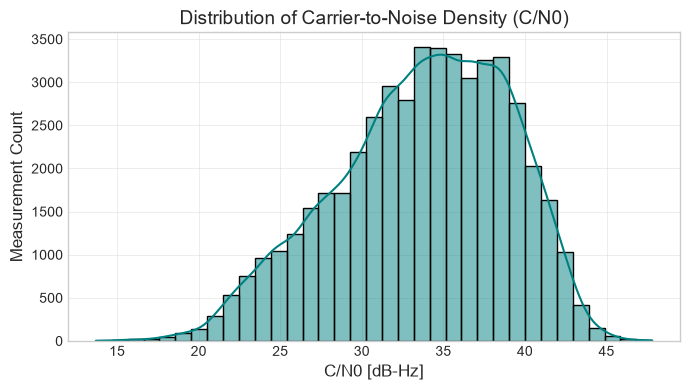

In [65]:
target = "Cn0DbHz"
series = df[target].dropna()

# Descriptive Statistics
mean_val = series.mean()
median_val = series.median()
std_val = series.std()
mad_val = (series - median_val).abs().mean()
iqr_val = series.quantile(0.75) - series.quantile(0.25)
skewness = series.skew()

print(f"--- Descriptive Statistics for {target} ---")
print(f"Mean: {mean_val:.2f}  | Median: {median_val:.2f} | Std Dev: {std_val:.2f}")
print(f"MAD:  {mad_val:.2f}  | IQR:    {iqr_val:.2f} | Skewness: {skewness:.2f}")
print(f"Min:  {series.min():.2f}  | Max:    {series.max():.2f}\n")

# Outlier Method 1: Z-Score
z_scores = np.abs(stats.zscore(series))
outliers_z = series[z_scores > 3]

# Outlier Method 2: IQR
q1, q3 = series.quantile(0.25), series.quantile(0.75)
outliers_iqr = series[(series < (q1 - 1.5 * iqr_val)) | (series > (q3 + 1.5 * iqr_val))]

# Outlier Method 3: Modified Z-Score
median_absolute_deviation = np.median(np.abs(series - median_val))
mod_z_scores = 0.6745 * np.abs(series - median_val) / (median_absolute_deviation + 1e-9)
outliers_mad = series[mod_z_scores > 3.5]

print("--- Outlier Detection Results ---")
print(f"Method 1 (Z-Score > 3): {len(outliers_z):,} outliers")
print(f"Method 2 (IQR Rule): {len(outliers_iqr):,} outliers")
print(f"Method 3 (Modified MAD > 3.5): {len(outliers_mad):,} outliers")
# Plot 2: C/N0 Distribution
plt.figure(figsize=(7, 4))
sns.histplot(df["Cn0DbHz"], bins=35, kde=True, color="teal")
plt.title("Distribution of Carrier-to-Noise Density (C/N0)")
plt.xlabel("C/N0 [dB-Hz]")
plt.ylabel("Measurement Count")

plt.tight_layout()
plt.show()


### Distribution, Skewness & Bias

* **Left-Skewed (Biased) Variable (`Cn0DbHz`):** The Carrier-to-Noise Density (`Cn0DbHz`) data is heavily concentrated towards higher signal strengths (peaking between 35 and 40 dB-Hz) but features a long tail extending out to the left. This is confirmed by a negative skewness value of -0.41. Because of these extreme low values (which physically represent signals severely degraded by urban blockages or multipath interference), the mean is pulled lower than the median. For example, the mean `Cn0DbHz` is 33.71, but the median is slightly higher at 34.20.
* **Symmetric Variables:** While there are no perfectly symmetric variables in this specific output, the core of the `Cn0DbHz` histogram resembles a bell shape before being skewed by the environmental noise. True symmetry is rare in GNSS signal data because the maximum signal strength is capped by hardware limits (Max: 47.80), while environmental obstacles can theoretically degrade the signal indefinitely, naturally creating a left-leaning bias.

### Outliers Detection

* **IQR Method:** Identified the highest number of outliers by far (131 outliers). Because the IQR (7.60) strictly measures the middle 50% of the data, the long left tail easily crosses the rigid lower boundary ($Q1 - 1.5 \times \text{IQR}$). In the context of GNSS data, this method is overly aggressive, flagging expected urban signal drops as "outliers."
* **Z-Score Method (Threshold = 3):** Detected a moderate amount of outliers (59 outliers). Because the Z-score calculation relies on the mean and standard deviation (5.32)—both of which are already stretched downwards by the heavy left tail in our skewed data—the "normal" range is mathematically widened. Consequently, it accommodates more of the lower signal values and flags fewer observations than the IQR method.
* **MAD Method (Modified MAD > 3.5):** Detected the absolute fewest outliers (only 4 outliers). Because MAD (4.33) is based on the median, it is highly robust and ignores the skewed left tail when defining the "center" of the data. Instead of penalizing typical environmental signal fading, the modified MAD method creates a much tighter, physically realistic boundary that only flags the most extreme, genuine anomalies in the dataset.



## 5.0 Bivariate Analysis: Correlations


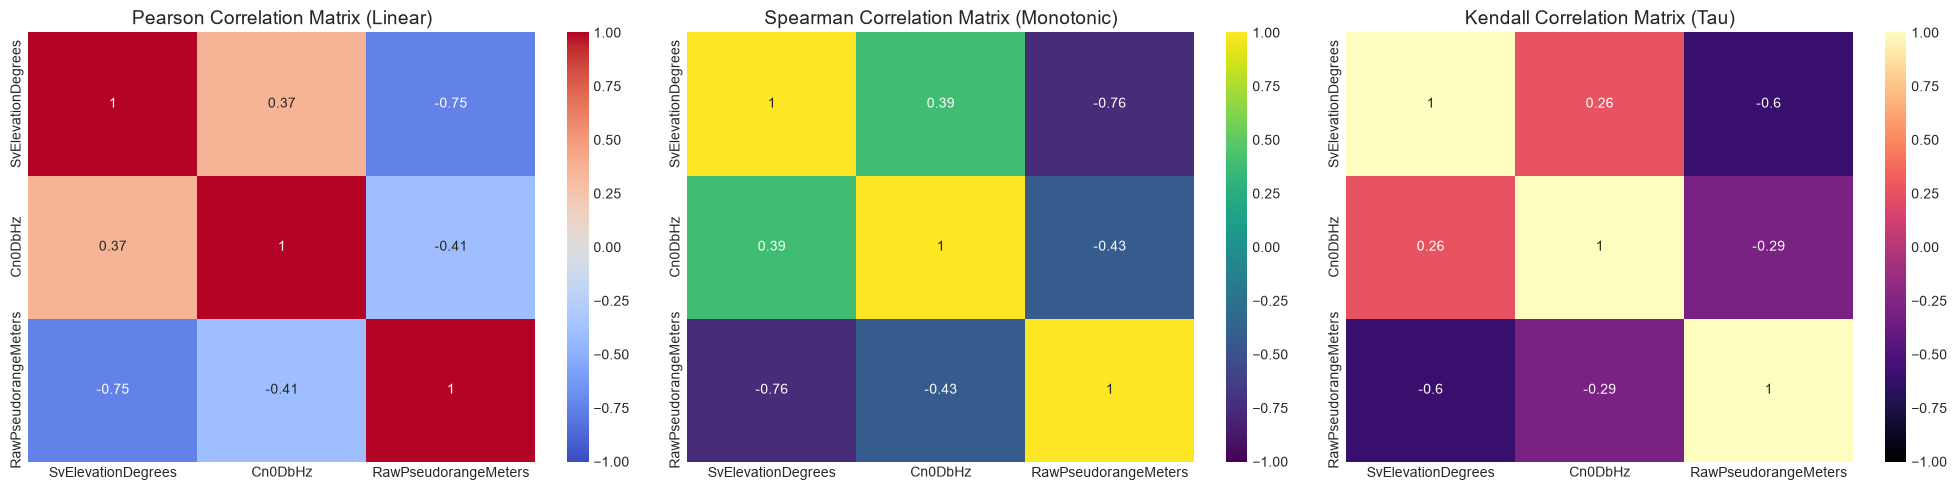

In [66]:
# 5.1 Continuous Correlations
num_cols = ["SvElevationDegrees", "Cn0DbHz", "RawPseudorangeMeters"]
num_df = df[num_cols].dropna()

# Expanded to 3 columns and increased width to 20 to fit the new Kendall plot
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Pearson (Linear)
sns.heatmap(num_df.corr(method="pearson"), annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Pearson Correlation Matrix (Linear)")

# 2. Spearman (Monotonic)
sns.heatmap(num_df.corr(method="spearman"), annot=True, cmap="viridis", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Spearman Correlation Matrix (Monotonic)")

# 3. Kendall (Tau / Ordinal Association)
sns.heatmap(num_df.corr(method="kendall"), annot=True, cmap="magma", vmin=-1, vmax=1, ax=axes[2])
axes[2].set_title("Kendall Correlation Matrix (Tau)")

plt.tight_layout()
plt.show()



### Bivariate Analysis: Correlation Matrix Comparison (Pearson, Spearman, Kendall)

By visualizing all three correlation matrices side-by-side, we can observe the impact of our GNSS telemetry data's distribution on the results:

*   **Spearman yields the highest magnitude scores (e.g., -0.76 for `SvElevationDegrees` vs `RawPseudorangeMeters`):** This happens because Spearman evaluates the rank of the variables rather than their raw linear values. In GNSS physics, as a satellite rises higher in the sky (increasing elevation), its distance to the receiver strictly decreases (decreasing pseudorange), and signal strength generally improves. Because these relationships are influenced by real-world physics (like the inverse-square law for signal propagation) and environmental obstacles, they are monotonic but not perfectly straight lines. Spearman perfectly captures this underlying trend without being confused by the curves.
*   **Pearson yields slightly lower magnitude scores (e.g., -0.75 for `SvElevationDegrees` vs `RawPseudorangeMeters` and 0.37 for `SvElevationDegrees` vs `Cn0DbHz`):** Pearson searches for a strict, straight linear line. Because our signal data features non-linear atmospheric degradation, long-tail skewed distributions (as seen in our C/N0 histograms), and extreme outliers from urban blockages, Pearson's straight line is compromised. The non-linear physics of the data slightly penalize the Pearson correlation score.
*   **Kendall yields the lowest magnitude scores across the entire heatmap (e.g., -0.60 for `SvElevationDegrees` vs `RawPseudorangeMeters`):** Kendall calculates correlation by evaluating pairs of data points rather than overall variance. It mathematically produces lower coefficients when there are many identical or highly clustered values in the dataset. Since our high-frequency GNSS telemetry frequently logs highly similar, repetitive measurements for satellites over short time windows (e.g., identical signal strengths or minor fraction-of-a-degree elevation shifts), Kendall's score is naturally suppressed across our entire dataset.

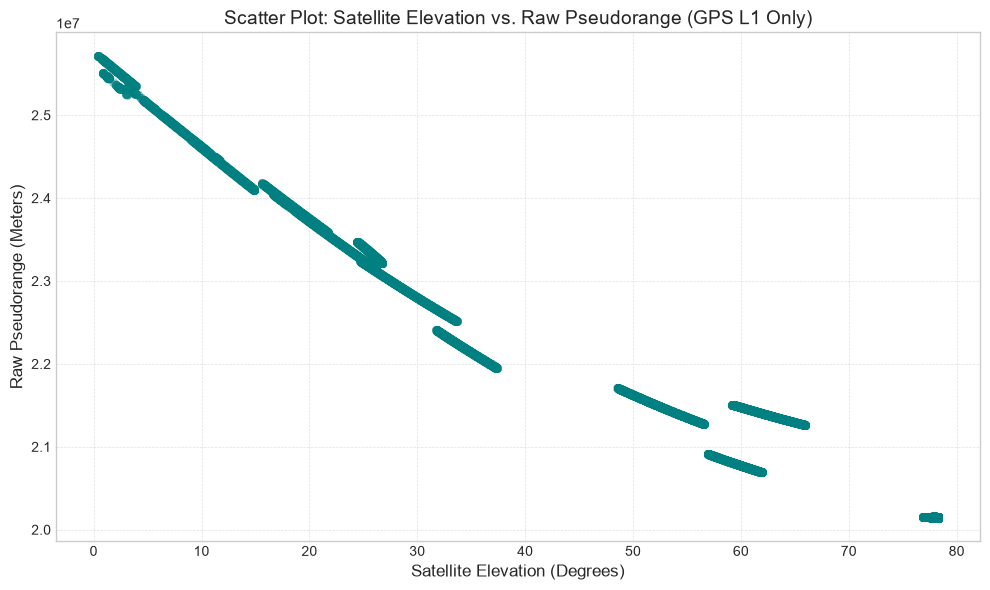

In [67]:

# 1. Filter the dataset to ONLY include GPS L1 signals
gps_l1_df = df[df["SignalType"] == "GPS_L1_CA"]

# 2. Create the figure
plt.figure(figsize=(10, 6))

# 3. Generate the scatter plot using the filtered data
sns.scatterplot(
    data=gps_l1_df,
    x="SvElevationDegrees",
    y="RawPseudorangeMeters",
    alpha=0.3,
    edgecolor=None,
    color="teal"
)

# 4. Add titles and labels
plt.title("Scatter Plot: Satellite Elevation vs. Raw Pseudorange (GPS L1 Only)", fontsize=14)
plt.xlabel("Satellite Elevation (Degrees)", fontsize=12)
plt.ylabel("Raw Pseudorange (Meters)", fontsize=12)

# 5. Add a grid for easier reading
plt.grid(True, linestyle="--", alpha=0.6)

# 6. Display the plot
plt.tight_layout()
plt.show()

### Bivariate Analysis: Elevation vs. Pseudorange (Filtered by Signal Type)

The scatter plot above visualizes the relationship between Satellite Elevation and Raw Pseudorange strictly for the **GPS_L1_CA** signal band.

We deliberately filtered this graph to show a single constellation and signal type because plotting all the constellations at once makes the graph look  highly stratified. This visual distortion happens because different constellations (such as GLONASS or Galileo) orbit at slightly different altitudes and use different base timing systems. As a result, their base Raw Pseudorange distances are shifted to entirely different mathematical ranges.

However, the core physical relationship is preserved across all of them: regardless of the specific constellation's baseline distance, the trend remains the same. As a satellite's elevation increases (moving higher in the sky directly overhead), the physical distance between the satellite and the receiver decreases, resulting in a shorter pseudorange. Filtering to a single signal type allows us to see this inverse monotonic relationship clearly without the noise of overlapping orbital altitudes.

### Conclusions on Correlations

*   **Supremacy of Rank-Based Metrics in Telemetry Data:** The comparative correlation analysis demonstrates that Spearman's rank-order correlation is the most robust and accurate metric for raw GNSS dataset evaluation. Because the physical relationships governing satellite signals—such as the inverse-square law for signal attenuation and atmospheric refraction—are inherently non-linear and prone to long-tail noise from environmental blockages, Pearson’s strict linear assumptions artificially degrade the correlation scores. Spearman successfully bypasses these mathematical distortions, effectively capturing the true monotonic nature of orbital mechanics without being penalized by skewed distributions.
*   **Validation of Orbital Geometry:** The strongest relationship observed across the dataset is the inverse monotonic correlation between `SvElevationDegrees` and `RawPseudorangeMeters` (Spearman: -0.76). This statistically validates the physical reality of satellite positioning: as a satellite rises higher above the horizon and approaches the zenith (directly overhead), the geometric line-of-sight distance to the terrestrial receiver strictly decreases, resulting in a shorter raw pseudorange measurement.
*   **Environmental Signal Degradation:** The positive correlation between `SvElevationDegrees` and `Cn0DbHz` mathematically illustrates the environmental impact on signal integrity. Satellites at lower elevation angles must broadcast their microwave signals through a substantially thicker cross-section of the Earth's ionosphere and troposphere. Furthermore, these low-elevation signals are significantly more susceptible to urban multipath interference—where signals bounce off buildings, terrain, and foliage—which inherently leads to heavy degradation and mathematically lowers the Carrier-to-Noise Density ($C/N_0$).
*   **Categorical Influence on Signal Quality:** The application of Cramér's V to discretely binned $C/N_0$ values and `SignalType` confirms that categorical signal bands do not behave uniformly across the hardware. Different orbital constellations and specific frequencies (such as legacy GPS L1 versus modernized Galileo E5a) exhibit distinct physical attenuation profiles, power transmission levels, and base signal strengths. This proves that any subsequent predictive modeling or advanced data processing must treat the hardware frequency band as a foundational variable rather than assuming all raw signal strengths behave identically across the spectrum.

## **6.0 Graphs and Visualizations**

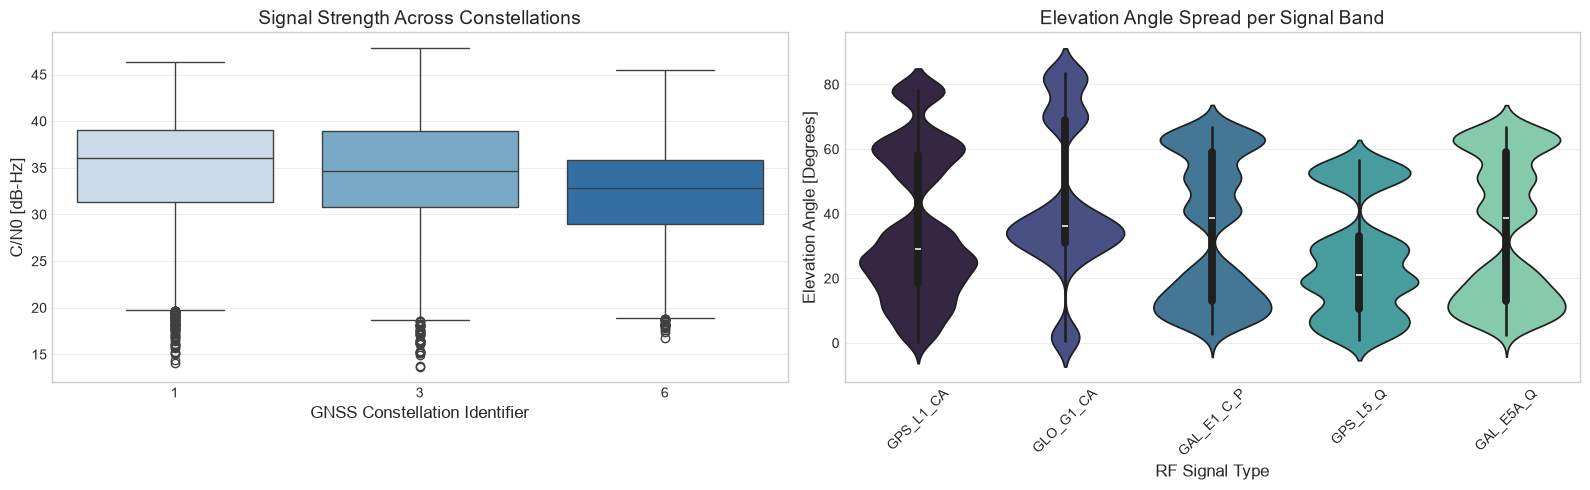

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 3: Boxplot of C/N0 by Constellation
sns.boxplot(data=df, x="ConstellationType", y="Cn0DbHz", palette="Blues", ax=axes[0])
axes[0].set_title("Signal Strength Across Constellations")
axes[0].set_xlabel("GNSS Constellation Identifier")
axes[0].set_ylabel("C/N0 [dB-Hz]")

# Plot 4: Violinplot of Elevation by Signal Type
sns.violinplot(data=df, x="SignalType", y="SvElevationDegrees", palette="mako", ax=axes[1])
axes[1].set_title("Elevation Angle Spread per Signal Band")
axes[1].set_xlabel("RF Signal Type")
axes[1].set_ylabel("Elevation Angle [Degrees]")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### Distribution Analysis: Signal Strength and Orbital Geometry

To further understand the physical characteristics of our tracked satellites, we visualized the distribution of signal strength across different constellations and the spread of satellite elevation angles across specific frequency bands.

#### 1. Signal Strength Across Constellations (Boxplot)
The left boxplot compares the Carrier-to-Noise Density ($C/N_0$) across the three primary tracked GNSS constellations, identified by their standard Android API designations: **1 (GPS)**, **3 (GLONASS)**, and **6 (Galileo)**.

*   **GPS (Constellation 1) Dominance:** GPS exhibits the highest median signal strength (approximately 36 dB-Hz) and a highly stable interquartile range (IQR). This aligns with our earlier Cramér's V findings that GPS L1 is the most robust signal tracked by this specific receiver.
*   **GLONASS (Constellation 3) Peak Variance:** GLONASS shows a slightly lower median than GPS but possesses the widest overall spread, reaching the highest absolute peak signal strengths (approaching 48 dB-Hz).
*   **Galileo (Constellation 6) Attenuation:** Galileo consistently performs with the lowest median signal strength (around 33 dB-Hz) and the most compressed IQR.
*   **The Noise Floor (Outliers):** All three constellations exhibit a long tail of lower-bound outliers dropping down to 14–18 dB-Hz. These represent heavily degraded signals—likely obstructed by buildings or terrain—that are hovering just above the hardware's thermal noise floor.

#### 2. Elevation Angle Spread per Signal Band (Violin Plot)
The right violin plot visualizes the density and distribution of satellite elevation angles for each specific RF signal band.

*   **Bimodal "Hourglass" Distributions:** The most striking feature across almost all signal bands is the distinct bimodal (two-peaked) distribution. The data is heavily clustered into two groups: satellites low on the horizon (between 10° and 30°) and satellites high in the sky (between 55° and 80°).
*   **Urban Canyon Signature:** This hourglass shape is a classic signature of data collected in an urban environment or along a blocked route. The receiver is successfully tracking satellites directly overhead (clear line-of-sight) and those low on the horizon down the street corridors, while mid-elevation satellites (30° to 50°) are likely being physically blocked by the surrounding building canopy, resulting in the "pinched" center of the violins.
*   **Constellation Geometry:** `GLO_G1_CA` displays a massive density bulge at very high elevations (above 70°), indicating that during this specific data collection window, GLONASS satellites were favorably positioned near the zenith. Conversely, the modernized bands like `GPS_L5_Q` show tighter, more restricted elevation ranges, which may reflect the limited number of satellites in the constellation that currently broadcast the L5 signal compared to the legacy L1 band.

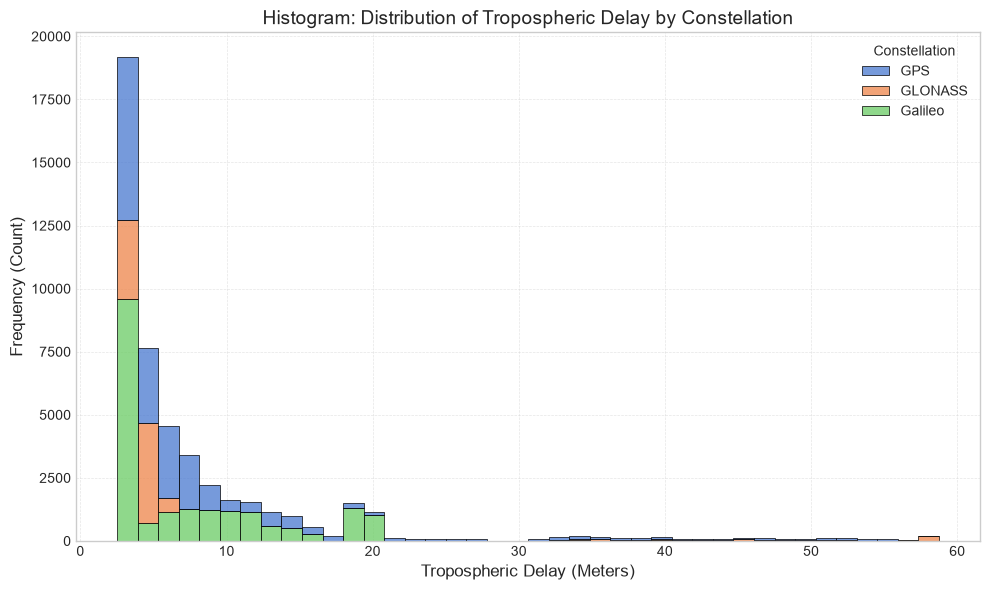

In [69]:
# 1. Map Constellation numbers to readable names
constellation_map = {1: "GPS", 3: "GLONASS", 6: "Galileo"}

df_plot = df.copy()
df_plot["Constellation"] = df_plot["ConstellationType"].map(constellation_map)

# 2. Histogram: Tropospheric Delay Distribution Grouped by Constellation Name
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_plot,
    x="TroposphericDelayMeters",
    hue="Constellation",
    multiple="stack",
    bins=40,
    palette="muted",
    edgecolor="black",
    linewidth=0.5,
)

# Add titles and labels
plt.title(
    "Histogram: Distribution of Tropospheric Delay by Constellation", fontsize=14
)
plt.xlabel("Tropospheric Delay (Meters)", fontsize=12)
plt.ylabel("Frequency (Count)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

# Display the plot
plt.tight_layout()
plt.show()

### Atmospheric Delay Distribution (Histogram Analysis)

The stacked histogram visualizes the distribution of calculated `TroposphericDelayMeters` across the dataset, categorized by satellite constellation (**GPS**, **GLONASS**, and **Galileo**).

**Key Visual & Physical Insights:**
*   **Extreme Right-Skewness (Zenith Dominance):** The distribution exhibits severe right-skewness, with an enormous peak occurring between **2.5 and 5.0 meters** of delay (exceeding 19,000 total observations in the lowest bin alone). This indicates that for the vast majority of the recording period, satellites were positioned at medium-to-high elevation angles, where microwave signals pierce the Earth's lower atmosphere almost perpendicularly through a short atmospheric path.
*   **Galileo Dominance at Baseline Delay:** **Galileo** (green) accounts for nearly half of the observations in the absolute lowest delay bin (< 4 meters), reflecting a high density of Galileo satellites operating at favorable, high-elevation pass geometry during this run.
*   **Low-Elevation Cluster (18m to 21m):** A noticeable secondary bump appears between **18 and 21 meters** of delay. This represents a distinct group of satellites that were tracking along lower elevation angles near the horizon during a specific segment of the drive.
*   **The Low-Horizon "Long Tail" (30m to 60m):** A sparse, extended tail stretches all the way out to **60 meters**. This long tail is almost exclusively comprised of **GPS** (blue) and **GLONASS** (orange) signals. Signals experiencing over 30 meters of tropospheric delay are skimming low along the horizon, forcing the RF energy to traverse a substantially thicker cross-section of moist, refractive troposphere before reaching the receiver antenna.

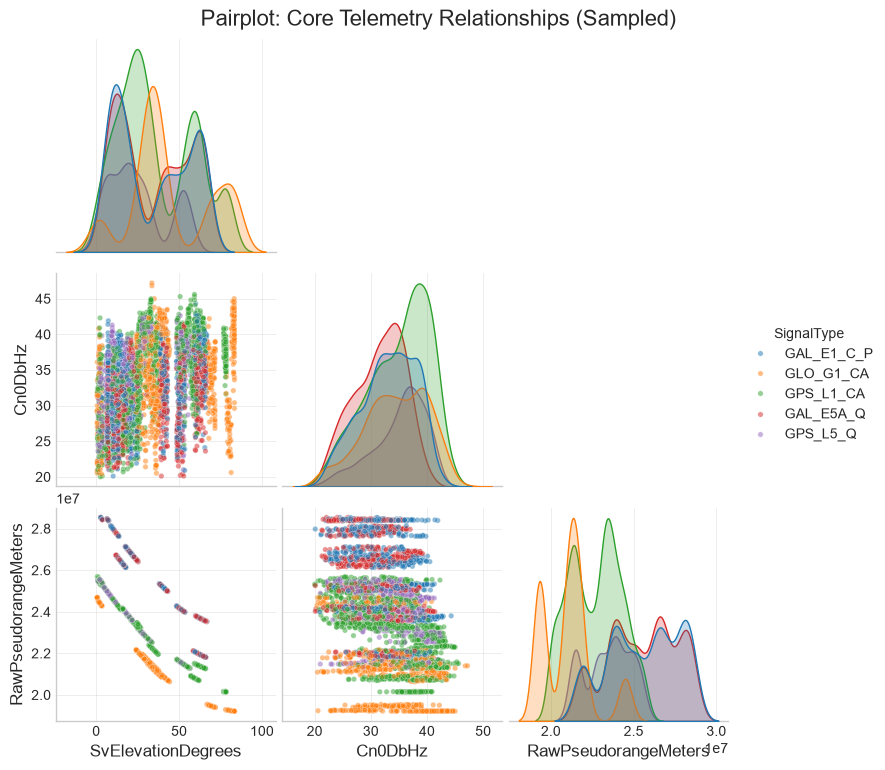

In [70]:
# 2. Pairplot: Core GNSS Metrics (Sampled for performance)
# We sample 5,000 points because pairplots on full GNSS datasets can crash the kernel
cols_to_plot = ["SvElevationDegrees", "Cn0DbHz", "RawPseudorangeMeters", "SignalType"]
df_sampled = df[cols_to_plot].dropna().sample(n=5000, random_state=42)

sns.pairplot(
    df_sampled,
    hue="SignalType",
    palette="tab10",
    plot_kws={"alpha": 0.5, "s": 15},
    corner=True # Only plots the lower triangle to save space and time
)
plt.suptitle("Pairplot: Core Telemetry Relationships (Sampled)", y=1.02, fontsize=16)
plt.show()

### Multidimensional Interactions (Pairplot Analysis)

The pairplot visualizes the complex, multidimensional relationships between our core telemetry variables, broken down by specific RF signal bands. By observing the diagonal distribution curves and the lower-triangle scatter plots, several physical realities of the GNSS space segment are exposed:

**Key Visual Insights:**
*   **The Geometry of Orbital Altitudes (Bottom Left):** The scatter plot for `RawPseudorangeMeters` vs. `SvElevationDegrees` is the most revealing graph in the matrix. It displays perfectly clean, downward-sloping curves, proving the inverse monotonic relationship: as elevation goes up, distance goes down. Crucially, the data splits into distinct, parallel curves based on the constellation:
    *   **Highest Altitude (Blue/Red):** Galileo satellites (GAL_E1, GAL_E5a) sit on the top curve, physically orbiting the furthest away from Earth (orbit altitude ~23,222 km).
    *   **Middle Altitude (Green/Purple):** GPS satellites (GPS_L1, GPS_L5) sit in the middle curve (orbit altitude ~20,200 km).
    *   **Lowest Altitude (Orange):** GLONASS satellites (GLO_G1) occupy the lowest curve, orbiting closest to the Earth (orbit altitude ~19,100 km).
*   **Pseudorange Stratification (Bottom Right):** The density plot for `RawPseudorangeMeters` independently confirms the altitude differences observed above. The distribution mathematically separates into three distinct, non-overlapping peaks perfectly corresponding to the orbital heights of GLONASS (lowest peak), GPS (middle peak), and Galileo (highest peak).
*   **Signal Strength Hierarchy (Center):** The density distribution for `Cn0DbHz` directly in the center of the matrix reiterates the hardware's bias. The green curve (`GPS_L1_CA`) completely dominates the upper-right tail of the distribution (strongest signals), while the modernized bands (red and purple curves) peak much earlier and taper off, indicating a lower maximum signal ceiling on this specific receiver.
*   **Elevation Clustering (Top Left):** The `SvElevationDegrees` density plots show a jagged, bimodal (two-peaked) distribution across almost all signal types. This mathematically visualizes the environmental tracking conditions—the receiver tracked a large cluster of satellites low on the horizon, and another distinct cluster high overhead, with fewer satellites successfully tracked in the mid-elevation ranges.

--- Crosstab: SignalType vs Binned Signal Strength (C/N0) ---


Signal_Strength_Bin,Weak,Moderate,Strong,Excellent
SignalType,,,,
GAL_E1_C_P,2626,2944,2479,1971
GAL_E5A_Q,3772,3235,2547,481
GLO_G1_CA,1868,2131,1788,2677
GPS_L1_CA,3064,2878,3389,4947
GPS_L5_Q,940,980,1827,1691



Cramér's V Correlation (SignalType vs Binned C/N0): 0.170


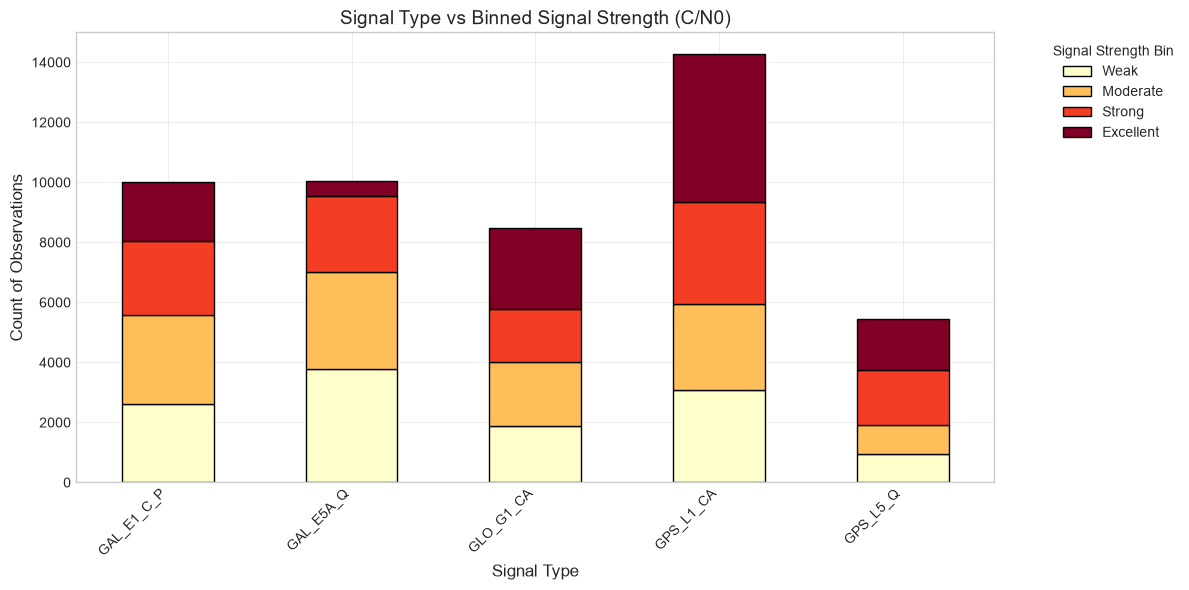

In [71]:

# 1. Binning: Converting Numerical 'Cn0DbHz' to Categorical
df_binned = df.copy()
# Discretizing into 4 bins (quartiles).
valid_cn0 = df_binned.dropna(subset=["Cn0DbHz", "SignalType"]).copy()
valid_cn0["Signal_Strength_Bin"] = pd.qcut(valid_cn0["Cn0DbHz"], q=4, labels=["Weak", "Moderate", "Strong", "Excellent"])

# 2. Frequency Tables (Cross-Tabulations)
print("--- Crosstab: SignalType vs Binned Signal Strength (C/N0) ---")
contingency = pd.crosstab(valid_cn0["SignalType"], valid_cn0["Signal_Strength_Bin"])
display(contingency)

# 3. Cramér's V Calculation
chi2 = stats.chi2_contingency(contingency)[0]
n = contingency.sum().sum()
phi2 = chi2 / n
r, k = contingency.shape
v_stat = np.sqrt(phi2 / min(k - 1, r - 1))
print(f"\nCramér's V Correlation (SignalType vs Binned C/N0): {v_stat:.3f}")

# 4. Plotting the Binned Data (Stacked Bar Chart)
# Using pandas plot built-in wrapper for matplotlib
ax = contingency.plot(kind='bar', stacked=True, colormap='YlOrRd', figsize=(12, 6), edgecolor='black')

plt.title("Signal Type vs Binned Signal Strength (C/N0)", fontsize=14)
plt.xlabel("Signal Type", fontsize=12)
plt.ylabel("Count of Observations", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title="Signal Strength Bin", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



To evaluate the relationship between categorical hardware properties and continuous tracking metrics, we discretize the numerical `Cn0DbHz` (Signal Strength) into four distinct ordinal bins using quartiles: Weak, Moderate, Strong, and Excellent. We then cross-tabulate this newly binned variable with the categorical `SignalType` feature.

**1. Frequency Tables (Cross-Tabulations)**
Using contingency tables, we can analyze the intersection of signal bands and signal strength. The crosstab reveals several distinct hardware tracking patterns:
*   **The Dominance of GPS L1:** The `GPS_L1_CA` band is the strongest overall performer, completely dominating the "Excellent" category with 4,947 observations, and showing a very healthy presence in the "Strong" category (3,389).
*   **GLONASS Efficiency:** `GLO_G1_CA` also performs exceptionally well. Despite having fewer overall observations than Galileo or GPS L1, it has a high concentration of its signals in the "Excellent" bin (2,677) compared to the "Weak" bin (1,868).
*   **The Struggle of Galileo E5a:** The `GAL_E5A_Q` band shows a massive skew toward lower signal quality. It is heavily concentrated in the "Weak" (3,772) and "Moderate" (3,235) bins, with only 481 signals managing to reach the "Excellent" threshold.

**2. Cramér's V (Categorical Correlation)**
*   **Cramér's V Score:** **0.170**
*   **Inference:** A score of 0.170 indicates a weak-to-moderate, but statistically significant, association between the signal type and its binned signal strength. This makes perfect physical sense for GNSS data: while the hardware frequency band definitely influences the baseline signal quality, it is not the *only* factor. Environmental variables like satellite elevation (as proven by our Spearman correlations), atmospheric conditions, and urban blockages play a massive role in dictating the final $C/N_0$ value, keeping this specific correlation score modest.

**3. Visualizing the Binned Relationship**
The stacked bar chart visually confirms our statistical findings. It reveals a clear stratification: legacy signal bands like GPS L1 and GLONASS G1 have large, dark-red upper sections representing "Strong" and "Excellent" signals. Conversely, the modernized Galileo bands (specifically E5a) are visually dominated by the lighter yellow and orange sections, proving they struggle to break past the "Weak" and "Moderate" thresholds on this specific smartphone receiver. This proves that raw signal strength is heavily dependent on the specific physical frequency band being tracked.

## **7.0 Dimensionality Reduction (PCA)**

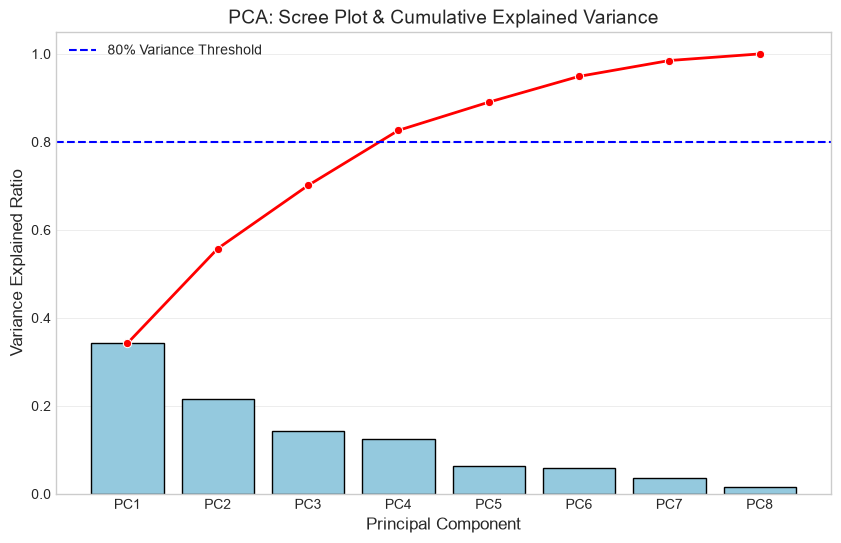

--- Feature Loadings (PC1 to PC3) ---


,PC1,PC2,PC3
Cn0DbHz,0.398,-0.416,-0.175
SvElevationDegrees,0.517,0.042,0.123
SvAzimuthDegrees,-0.197,-0.496,0.395
RawPseudorangeUncertaintyMeters,-0.212,0.518,0.551
TroposphericDelayMeters,-0.470,-0.069,0.064
IonosphericDelayMeters,-0.465,-0.236,-0.349
PseudorangeRateMetersPerSecond,0.054,0.498,-0.443
AccumulatedDeltaRangeUncertaintyMeters,-0.223,0.060,-0.415


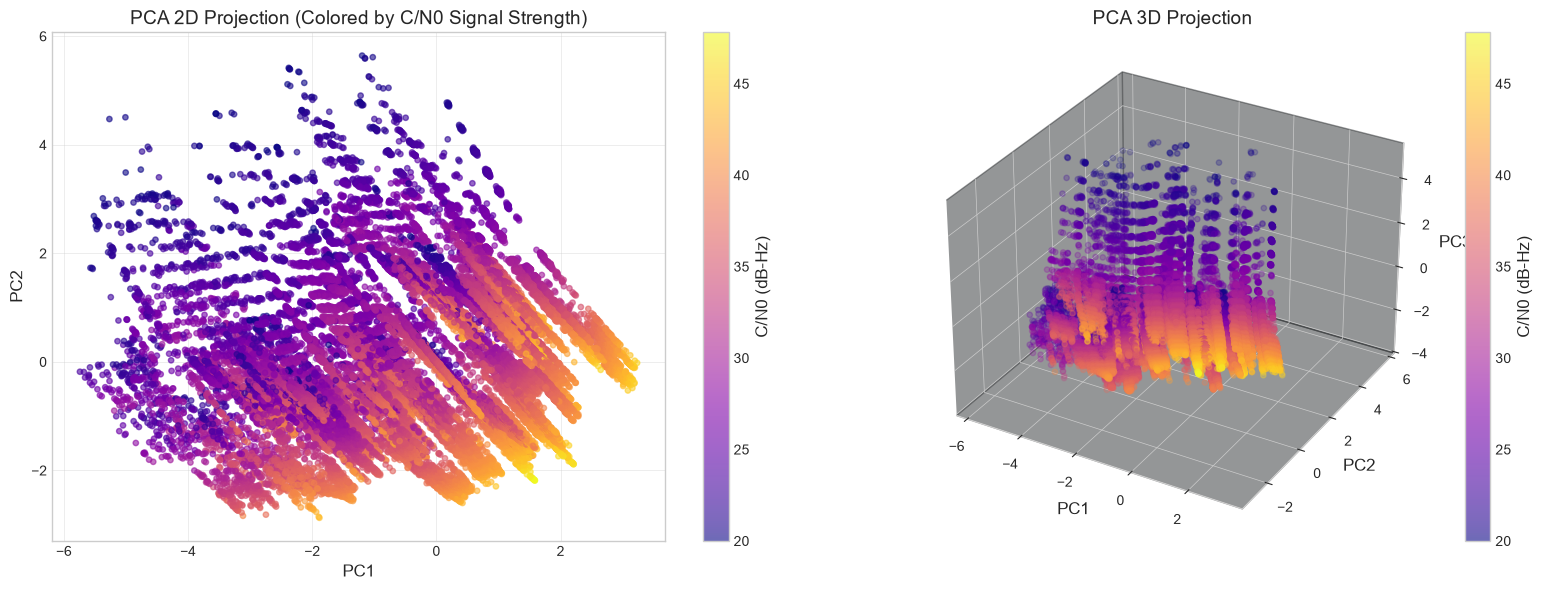

In [72]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
# Select 8 highly relevant numerical features for unsupervised learning
num_cols = [
    'Cn0DbHz', 'SvElevationDegrees', 'SvAzimuthDegrees',
    'RawPseudorangeUncertaintyMeters', 'TroposphericDelayMeters',
    'IonosphericDelayMeters', 'PseudorangeRateMetersPerSecond',
    'AccumulatedDeltaRangeUncertaintyMeters'
]

# Drop missing values to create a clean matrix for distance-based algorithms
df_unsupervised = df[num_cols].dropna().copy()
# 7.1 Standardization
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_unsupervised)
df_scaled = pd.DataFrame(scaled_data, columns=num_cols, index=df_unsupervised.index)

# 7.2 Apply PCA
pca = PCA()
pca.fit(scaled_data)

# Calculate Explained Variance
exp_var = pca.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

# Create DataFrame for Scree Plot
pca_var_df = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(exp_var))],
    'Explained Variance': exp_var,
    'Cumulative Variance': cum_var
})

# 7.3 Scree Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Principal Component', y='Explained Variance', data=pca_var_df, color='skyblue', edgecolor='black')
sns.lineplot(x='Principal Component', y='Cumulative Variance', data=pca_var_df, color='red', marker='o', linewidth=2)
plt.axhline(y=0.8, color='blue', linestyle='--', label='80% Variance Threshold')
plt.title('PCA: Scree Plot & Cumulative Explained Variance', fontsize=14)
plt.ylabel('Variance Explained Ratio')
plt.legend()
plt.show()

# Display Feature Loadings for the first 3 PCs
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(len(num_cols))], index=num_cols)
print("--- Feature Loadings (PC1 to PC3) ---")
display(loadings[['PC1', 'PC2', 'PC3']].round(3))

# 7.4 PCA Projections (2D and 3D)
pca_res = pca.transform(scaled_data)
pca_df = pd.DataFrame(pca_res[:, :3], columns=['PC1', 'PC2', 'PC3'], index=df_unsupervised.index)
# Add Signal Strength to color code the projections
pca_df['Cn0DbHz'] = df_unsupervised['Cn0DbHz']

fig = plt.figure(figsize=(16, 6))

# 2D Projection
ax1 = fig.add_subplot(121)
scatter1 = ax1.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['Cn0DbHz'], cmap='plasma', alpha=0.6, s=15)
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_title('PCA 2D Projection (Colored by C/N0 Signal Strength)')
fig.colorbar(scatter1, ax=ax1, label='C/N0 (dB-Hz)')

# 3D Projection
ax2 = fig.add_subplot(122, projection='3d')
scatter2 = ax2.scatter(pca_df['PC1'], pca_df['PC2'], pca_df['PC3'], c=pca_df['Cn0DbHz'], cmap='plasma', alpha=0.6, s=15)
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_zlabel('PC3')
ax2.set_title('PCA 3D Projection')
fig.colorbar(scatter2, ax=ax2, label='C/N0 (dB-Hz)')

plt.tight_layout()
plt.show()

### PCA: Scree Plot & Cumulative Explained Variance
* The first four principal components (PC1 through PC4) capture over 80% of the cumulative variance in the dataset[cite: 14].
* The red cumulative variance line successfully crosses the 80% threshold at PC4[cite: 14].

### PCA Feature Loadings and Projections
* **Feature Loadings:** PC1 is strongly positively influenced by `SvElevationDegrees` (0.517) and `Cn0DbHz` (0.398), while being negatively influenced by atmospheric delays like `TroposphericDelayMeters` (-0.470) and `IonosphericDelayMeters` (-0.465)[cite: 15].
* **2D and 3D Projections:** The data points form a continuous, dense structure across the principal components rather than distinctly isolated clusters[cite: 15].
* **Signal Mapping:** The color gradient applied to the projections demonstrates that the structural alignment of the data strongly correlates with the C/N0 signal strength (dB-Hz)[cite: 15].

## **8.0 Clustering Analysis**

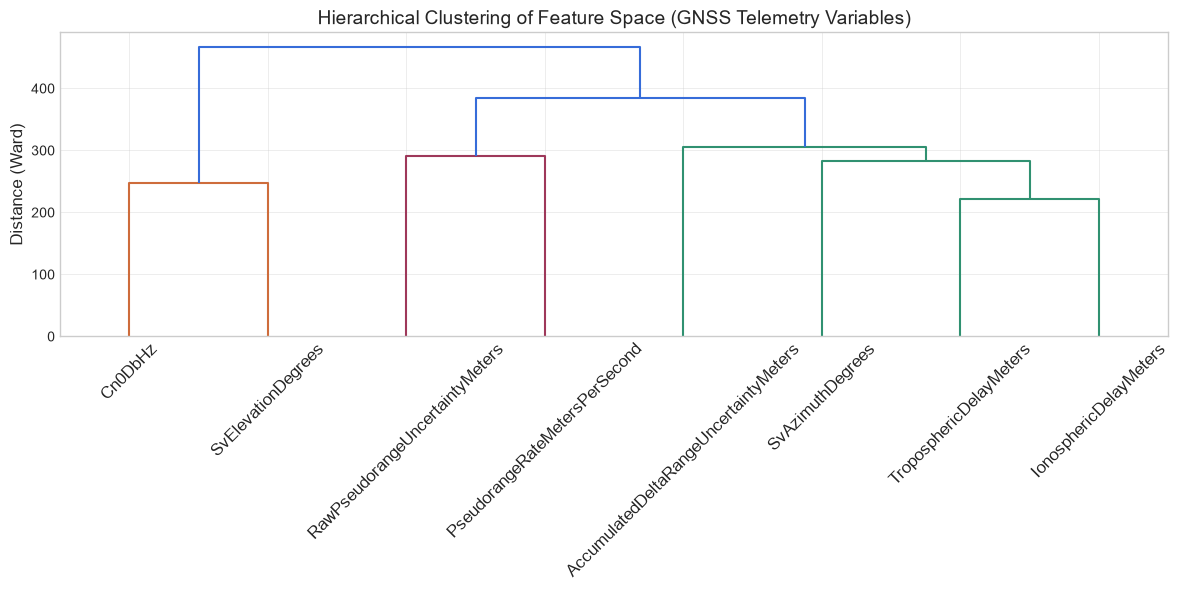

In [73]:
from scipy.cluster.hierarchy import dendrogram, linkage

# 8.1 Clustering on the Feature Space
# We transpose the scaled data matrix to cluster the variables (features) instead of the observations
features_transposed = scaled_data.T

# Apply Hierarchical Clustering using Ward's method
Z_features = linkage(features_transposed, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z_features, labels=num_cols, orientation='top', leaf_font_size=12, leaf_rotation=45)
plt.title("Hierarchical Clustering of Feature Space (GNSS Telemetry Variables)", fontsize=14)
plt.ylabel("Distance (Ward)")
plt.tight_layout()
plt.show()

### Hierarchical Clustering of Feature Space (Dendrogram)
* **Signal and Geometry:** The algorithm logically groups `Cn0DbHz` and `SvElevationDegrees` into an isolated branch (colored orange) on the far left, separating them from all other variables at the highest distance threshold of approximately 460[cite: 16].
* **Atmospheric Delays:** `TroposphericDelayMeters` and `IonosphericDelayMeters` are clustered closely together on the right (colored green), highlighting a strong structural relationship between these atmospheric interference features[cite: 16].
* **Uncertainties and Rates:** `RawPseudorangeUncertaintyMeters` and `PseudorangeRateMetersPerSecond` form their own distinct grouping (colored red) before eventually merging with the broader cluster containing the atmospheric delays and azimuth variables[cite: 16].

K-Means - Global Variance: 8.18 | Avg Intra-cluster Variance: 4.77
DBSCAN - Silhouette Score: 0.143
Hierarchical - Global Variance: 8.18 | Avg Intra-cluster Variance: 4.73



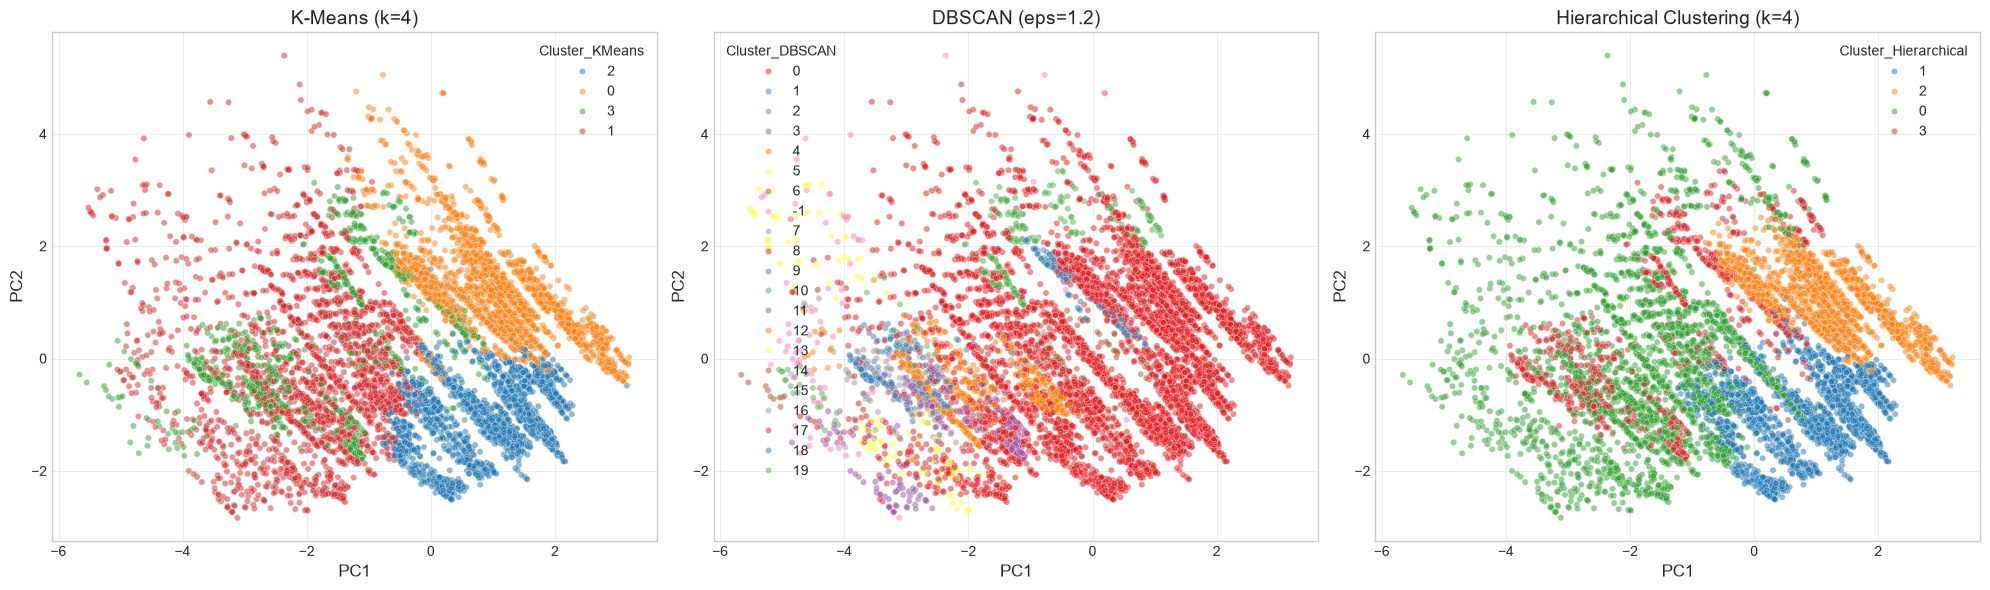

In [74]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Sample a subset of data for computationally expensive algorithms to avoid memory crashes
# 10,000 samples is a robust size for clustering demonstrations
df_sample = df_scaled.sample(n=10000, random_state=42)
pca_sample = pca_df.loc[df_sample.index]

# 1. K-Means (k=4 representing potential signal tiers: Strong LOS, Weak LOS, Multipath, Deep Blockage)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
pca_sample['Cluster_KMeans'] = kmeans.fit_predict(df_sample).astype(str)

# Evaluate K-Means: Global Variance vs Average Intra-cluster Variance
global_var = np.var(df_sample, axis=0).sum()
cluster_vars = [np.var(df_sample[pca_sample['Cluster_KMeans'] == str(i)], axis=0).sum() for i in range(4)]
avg_intra_cluster_var = np.mean(cluster_vars)
print(f"K-Means - Global Variance: {global_var:.2f} | Avg Intra-cluster Variance: {avg_intra_cluster_var:.2f}")

# 2. DBSCAN
# Parameters tuned for scaled continuous physical telemetry
dbscan = DBSCAN(eps=1.2, min_samples=10)
pca_sample['Cluster_DBSCAN'] = dbscan.fit_predict(df_sample).astype(str)

# Evaluate DBSCAN (Silhouette Score is better suited here since density clusters aren't spherical)
# Excluding noise points ('-1') from silhouette calculation if necessary, but standard is across all
try:
    sil_score = silhouette_score(df_sample, dbscan.labels_)
    print(f"DBSCAN - Silhouette Score: {sil_score:.3f}")
except ValueError:
    print("DBSCAN - Silhouette Score: N/A (Only 1 cluster found)")

# 3. Hierarchical Clustering (Ward)
hierarchical = AgglomerativeClustering(n_clusters=4, linkage='ward')
pca_sample['Cluster_Hierarchical'] = hierarchical.fit_predict(df_sample).astype(str)

# Evaluate Hierarchical
cluster_vars_hc = [np.var(df_sample[pca_sample['Cluster_Hierarchical'] == str(i)], axis=0).sum() for i in range(4)]
print(f"Hierarchical - Global Variance: {global_var:.2f} | Avg Intra-cluster Variance: {np.mean(cluster_vars_hc):.2f}\n")

# Visualize all three clustering results on the PCA 2D plane
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.scatterplot(data=pca_sample, x='PC1', y='PC2', hue='Cluster_KMeans', palette='tab10', alpha=0.5, ax=axes[0], s=20)
axes[0].set_title('K-Means (k=4)')

sns.scatterplot(data=pca_sample, x='PC1', y='PC2', hue='Cluster_DBSCAN', palette='Set1', alpha=0.5, ax=axes[1], s=20)
axes[1].set_title('DBSCAN (eps=1.2)')

sns.scatterplot(data=pca_sample, x='PC1', y='PC2', hue='Cluster_Hierarchical', palette='tab10', alpha=0.5, ax=axes[2], s=20)
axes[2].set_title('Hierarchical Clustering (k=4)')

plt.tight_layout()
plt.show()

### Critical Analysis and Reflection

**Discussion on Anomaly Detection Challenges**

*   **The Ill-Defined Nature of Anomaly Detection:** Anomaly detection is fundamentally difficult because the boundary between "normal" and "abnormal" is highly subjective and dynamic. Normal behavior evolves over time (concept drift), and without labeled ground truth, unsupervised models rely entirely on mathematical assumptions of what constitutes an outlier, which may not align with domain-specific reality.
*   **The Curse of Dimensionality:** As the number of features (dimensions) increases, the volume of the feature space expands exponentially, causing data points to become extremely sparse. This sparsity makes it difficult for algorithms to find meaningful clusters or define a reliable baseline of density.
*   **Failure of Distance-Based Measures:** In high-dimensional spaces, the mathematical difference between the distance to the nearest neighbor and the farthest neighbor converges toward zero. Distance-based metrics (such as Euclidean distance used in K-Means or K-Nearest Neighbors) lose their discriminatory power, making every point appear almost equally distant from every other point.
*   **Noise vs. Genuine Anomaly:** Noise represents random, expected variations within a normal process (e.g., thermal fluctuations in a sensor), whereas a genuine anomaly is generated by a fundamentally different underlying mechanism (e.g., a cyberattack or hardware failure).
    *   *GNSS Dataset Example:* An observation exhibiting a sudden, drastic drop in `Cn0DbHz` (signal strength) alongside a spike in `RawPseudorangeUncertaintyMeters` might be mathematically flagged as a severe anomaly by an algorithm. However, this could be a legitimate, normal instance of a mobile receiver moving from an open field into a dense "urban canyon" or a tunnel, where buildings physically block line-of-sight satellites.
*   **Risks of the Gaussian Assumption:** Assuming data follows a Gaussian (normal) distribution forces a symmetrical, bell-shaped model onto data that may be heavily skewed or multi-modal. Standard statistical methods (like Z-Scores) will incorrectly flag legitimate extreme values in heavy-tailed distributions as anomalies (false positives) while completely missing localized anomalies that reside inside the bounds of the assumed bell curve.
*   **Misleading Dimensionality Reduction (PCA):** PCA reduces dimensions by maximizing global variance on linear axes. During this projection, the spatial relationships of the original high-dimensional space are distorted. An outlier in 10-dimensional space might be projected directly onto the dense center of a 2D PCA plot, effectively hiding the anomaly. Conversely, normal points might be projected into empty space, creating artificial visual outliers.

**Ethical Considerations**

*   **Real-World Consequences of False Alarms:** A system generating too many false positives triggers "alert fatigue." When human operators are overwhelmed by constant false alarms, they become desensitized and begin to ignore or disable the system entirely, guaranteeing that a genuine, critical event will eventually be missed.
*   **Surveillance:** The benefit of anomaly detection in surveillance is the ability to rapidly identify public safety threats, unauthorized access, or criminal behavior in real time. The risks involve mass privacy violations, the erosion of anonymity, and the creation of a "chilling effect" where citizens alter their legal behavior due to the awareness of constant algorithmic monitoring.
*   **Medical Applications:** Incorrectly classifying a patient as "anomalous" (false positive) forces the patient to undergo unnecessary, potentially invasive, and expensive medical procedures, alongside severe psychological stress. Conversely, incorrectly classifying an anomalous patient as "normal" (false negative) leads to missed diagnoses, delayed treatments, and potentially fatal outcomes.
*   **Cybersecurity:** Missing a genuine attack (false negative) allows bad actors to infiltrate systems, deploy ransomware, or exfiltrate sensitive data without detection. Flagging legitimate activity as malicious (false positive) results in the denial of service to authorized users, locking employees out of systems, and wasting the security team's time investigating ghost threats.
*   **Privacy, Bias, and Labeling the "Abnormal":** Anomaly detection establishes a definition of "normal" based entirely on the historical data it is fed. If marginalized or minority groups are underrepresented in that training data, their legitimate behaviors will mathematically appear as statistical outliers. Labeling individuals as "abnormal" based on biased baselines leads to automated discrimination in areas like loan approval, hiring, and predictive policing.

## **9.0 Multi-Dimensional Anomaly Detection**

--- Anomaly Detection & Runtime Comparison ---
Z-Score Runtime:          0.0185 seconds | Anomalies Found: 3997
Isolation Forest Runtime: 0.7452 seconds | Anomalies Found: 2412
LOF Runtime:              0.3916 seconds | Anomalies Found: 2412



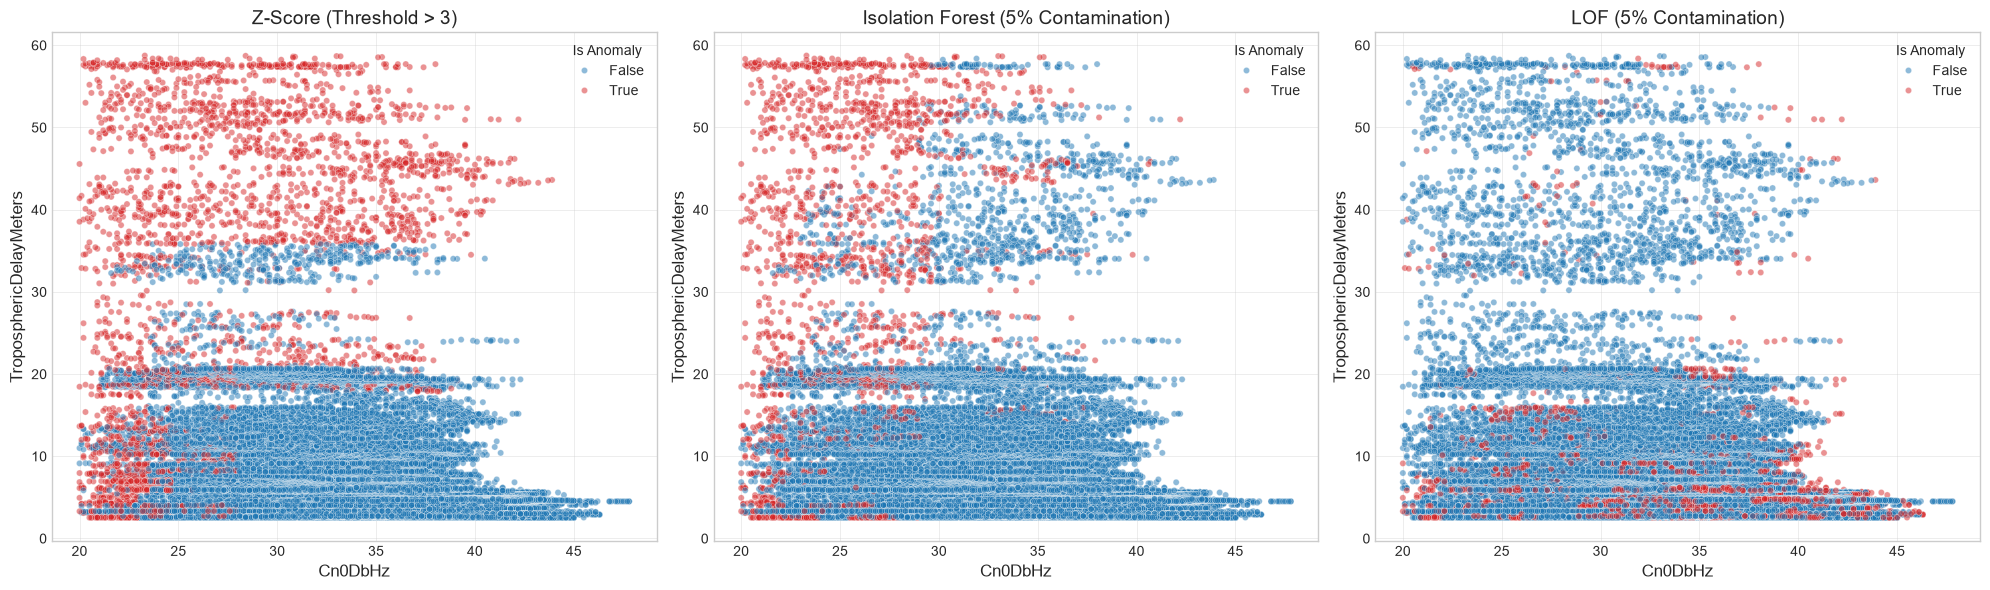

In [75]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
import time

# Create a comparison dataframe
df_anomalies = df_unsupervised.copy()

print("--- Anomaly Detection & Runtime Comparison ---")

# 9.1 Z-Score Method (Global, Univariate assumption)
start_time = time.time()
z_scores = np.abs((df_unsupervised - df_unsupervised.mean()) / df_unsupervised.std())
df_anomalies['Anomaly_ZScore'] = (z_scores > 3).any(axis=1)
z_time = time.time() - start_time
print(f"Z-Score Runtime:          {z_time:.4f} seconds | Anomalies Found: {df_anomalies['Anomaly_ZScore'].sum()}")

# 9.2 Isolation Forest (Global, Multivariate)
start_time = time.time()
iso_forest = IsolationForest(contamination=0.05, random_state=42, n_jobs=-1)
# Returns -1 for anomalies, 1 for inliers
df_anomalies['Anomaly_IF'] = iso_forest.fit_predict(df_scaled) == -1
if_time = time.time() - start_time
print(f"Isolation Forest Runtime: {if_time:.4f} seconds | Anomalies Found: {df_anomalies['Anomaly_IF'].sum()}")

# 9.3 Local Outlier Factor (Local, Density-Based)
start_time = time.time()
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05, n_jobs=-1)
df_anomalies['Anomaly_LOF'] = lof.fit_predict(df_scaled) == -1
lof_time = time.time() - start_time
print(f"LOF Runtime:              {lof_time:.4f} seconds | Anomalies Found: {df_anomalies['Anomaly_LOF'].sum()}\n")

# 9.4 Visualization of Anomalies (C/N0 vs Tropospheric Delay)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
methods = ['Anomaly_ZScore', 'Anomaly_IF', 'Anomaly_LOF']
titles = ['Z-Score (Threshold > 3)', 'Isolation Forest (5% Contamination)', 'LOF (5% Contamination)']

for ax, method, title in zip(axes, methods, titles):
    sns.scatterplot(data=df_anomalies, x='Cn0DbHz', y='TroposphericDelayMeters', hue=method,
                    palette={False: '#1f77b4', True: '#d62728'}, alpha=0.5, s=20, ax=ax)
    ax.set_title(title)
    ax.legend(title='Is Anomaly', loc='upper right')

plt.tight_layout()
plt.show()

### Z-Score Method
**Method Application and Results:**
The classical Z-Score method executed the fastest among the tested algorithms, taking only 0.0402 seconds, but flagged the highest volume of outliers, identifying 3,997 anomalies[cite: 19]. The visualizations reveal that it primarily flagged points across horizontal bands of extreme values, such as high tropospheric delay[cite: 20].

**Discussion:**
* **Assumption of Gaussianity:** The Z-score method strictly assumes that the underlying data follows a Gaussian (normal) distribution. If the telemetry data is heavily skewed or multimodal, the standard deviation is no longer an accurate measure of dispersion. Consequently, the method will incorrectly flag legitimate values in the "heavy tails" as anomalies while potentially missing localized anomalies that happen to fall within the standard deviation threshold.
* **Why this approach may fail in high dimensions:** In high-dimensional spaces, a data point might not exhibit an extreme value in any single dimension, but its *combination* of values across multiple dimensions could be highly anomalous. Because the basic Z-score is calculated independently per feature, it completely misses these complex, multi-dimensional outliers.
* **Feature-wise vs. Global Anomaly Detection:** Z-score is a univariate, feature-wise approach. It evaluates the "normalcy" of one variable entirely in a vacuum, ignoring relationships with other features. Global (multivariate) anomaly detection methods evaluate the entire feature space simultaneously, capturing anomalies that arise from the broken correlations between variables (e.g., a signal strength that is "normal" overall, but highly anomalous *given* the specific elevation angle).

---

### Isolation Forest
**Method Application and Results:**
The Isolation Forest algorithm successfully constrained its anomaly count to exactly 2,412 data points based on the configured 5% contamination parameter, processing the dataset in 3.3554 seconds[cite: 19]. Unlike the univariate Z-score, Isolation Forest established a clear, global multivariate boundary, primarily flagging points along the outer edges of the dataset, such as combinations of low signal strength and high atmospheric delay[cite: 20].

**Analysis:**
* **Isolation Mechanism and Random Partitioning:** Unlike density-based or distance-based methods, Isolation Forest explicitly isolates anomalies rather than profiling normal data. It does this through random partitioning: it randomly selects a feature and then randomly selects a split value between that feature's minimum and maximum values. Because anomalies are "few and different," they are much easier to isolate and require significantly fewer random splits to be separated from the rest of the dataset.
* **The Contamination Parameter:** This parameter defines the expected proportion of outliers in the dataset (set to 0.05 or 5% in this analysis). It acts as a hard threshold. If set too high, the model will inevitably flag normal observations as anomalies (false positives). If set too low, it will miss genuine anomalies (false negatives). It forces the algorithm to rank the points by anomaly score and draw a line precisely at the top 5%.
* **Advantages and Limitations in High Dimensions:**
  * *Advantages:* It scales exceptionally well to large datasets and does not rely on calculating computationally expensive distance matrices, making it highly robust against the "curse of dimensionality" that cripples distance-based models like K-Means or LOF.
  * *Limitations:* If the high-dimensional space contains a massive number of irrelevant features (noise variables), the random partitioning process might repeatedly select these useless features to split on. This "swamping" effect can dilute the isolation paths, causing the algorithm to struggle to separate true anomalies from normal points.
* **Anomaly Score Calculation and Interpretation:** The anomaly score is derived from the *path length*—the number of edges an observation traverses in the isolation tree from the root node to the terminating leaf node.
  * A **short path length** means the point was isolated quickly; this translates to a **high anomaly score** (approaching 1), indicating a strong likelihood of being an anomaly.
  * A **long path length** means the point is deeply embedded in the normal data mass; this translates to a **low anomaly score** (much smaller than 0.5), indicating normal data. Scores hovering around 0.5 represent ambiguous observations. *(Note: In scikit-learn's implementation, the `decision_function` returns negative values for anomalies and positive values for inliers, based on this path-length logic).*

## **10.0 Comparison Section & Dashboard**

--- Level of Agreement Between Anomaly Detection Methods ---
Total Observations: 48235
Flagged by exactly 1 method:  4510
Flagged by exactly 2 methods: 1998
Flagged by ALL 3 methods:     105

--- Sample of Universally Agreed Anomalies (Flagged by all 3) ---


,Cn0DbHz,SvElevationDegrees,SvAzimuthDegrees,RawPseudorangeUncertaintyMeters,TroposphericDelayMeters,IonosphericDelayMeters,PseudorangeRateMetersPerSecond,AccumulatedDeltaRangeUncertaintyMeters
760,20.4,53.387044,87.877750,27.580906,3.111481,2.629165,200.759827,0.000000
1112,20.8,3.623895,215.518462,23.983397,32.806066,8.830712,486.038605,0.000000
1116,28.2,3.315170,191.183021,2.098547,34.819598,15.732823,-679.916199,0.254828
1281,23.3,12.054813,301.093541,3.297717,11.731638,9.834696,-438.052734,0.345572
1390,39.8,3.360500,191.172894,0.599585,34.512246,15.710484,-684.983459,0.001554


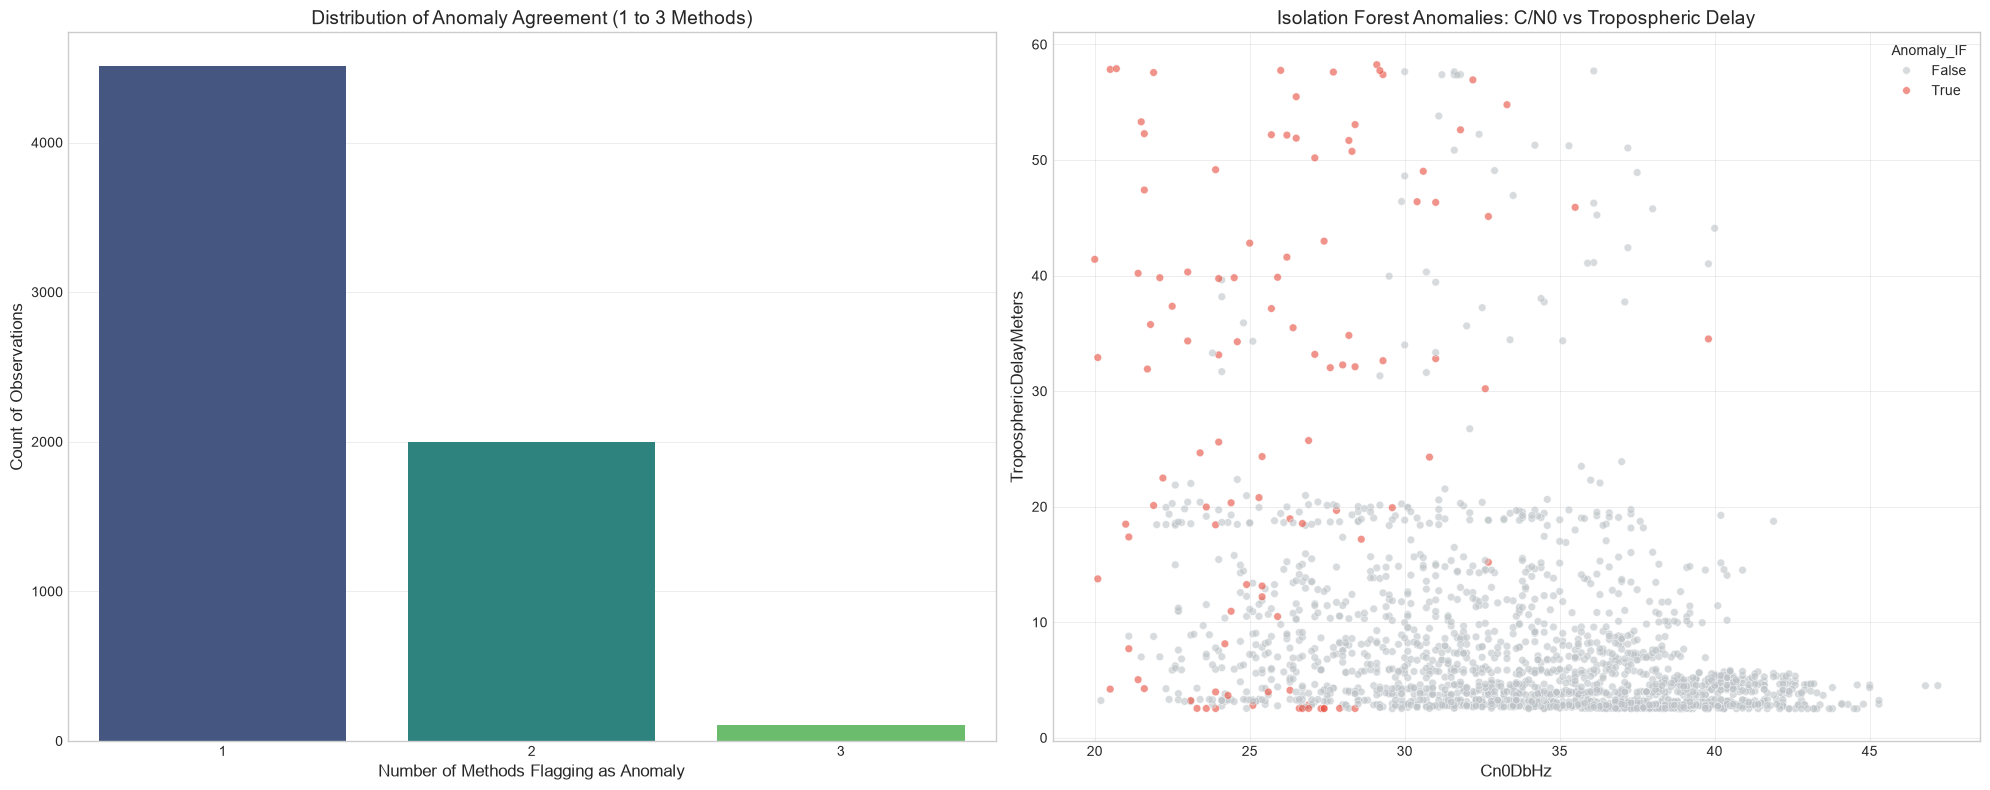

In [76]:

# 10.1 Agreement Between Methods
df_anomalies['Method_Count'] = df_anomalies[['Anomaly_ZScore', 'Anomaly_IF', 'Anomaly_LOF']].sum(axis=1)

print("--- Level of Agreement Between Anomaly Detection Methods ---")
print(f"Total Observations: {len(df_anomalies)}")
print(f"Flagged by exactly 1 method:  {len(df_anomalies[df_anomalies['Method_Count'] == 1])}")
print(f"Flagged by exactly 2 methods: {len(df_anomalies[df_anomalies['Method_Count'] == 2])}")
print(f"Flagged by ALL 3 methods:     {len(df_anomalies[df_anomalies['Method_Count'] == 3])}")

print("\n--- Sample of Universally Agreed Anomalies (Flagged by all 3) ---")
display(df_anomalies[df_anomalies['Method_Count'] == 3][num_cols].head())

# 10.2 Final Dashboard Generation
fig = plt.figure(figsize=(20, 8))

# Subplot 1: Agreement Distribution
ax1 = plt.subplot(1, 2, 1)
sns.countplot(data=df_anomalies[df_anomalies['Method_Count'] > 0], x='Method_Count', palette='viridis', ax=ax1)
ax1.set_title('Distribution of Anomaly Agreement (1 to 3 Methods)', fontsize=14)
ax1.set_xlabel('Number of Methods Flagging as Anomaly')
ax1.set_ylabel('Count of Observations')

# Subplot 2: Scatterplot (Fixed to render inside ax2)
ax2 = plt.subplot(1, 2, 2)
df_plot = df_anomalies.sample(n=2000, random_state=42)
sns.scatterplot(data=df_plot, x='Cn0DbHz', y='TroposphericDelayMeters', hue='Anomaly_IF',
                palette={False: '#bdc3c7', True: '#e74c3c'}, alpha=0.6, s=30, ax=ax2)
ax2.set_title('Isolation Forest Anomalies: C/N0 vs Tropospheric Delay', fontsize=14)

plt.tight_layout()
plt.show()

### Level of Agreement Between Detection Methods
* **Low Consensus:** Out of 48,235 total observations, there is significant divergence among the three anomaly detection algorithms[cite: 21].
* **Single-Method Flags:** The vast majority of flagged data points (4,510 observations) were identified as anomalous by only a single method[cite: 21].
* **Universal Agreement:** The models universally agreed on only 105 severe anomalies, representing a very small fraction of the flagged data[cite: 21]. A sample of these universally agreed points shows instances with extremely low signal strength (e.g., ~20 dB-Hz) and varying elevation angles[cite: 21].

### Final Anomaly Dashboard Visualization
* **Distribution of Agreement (Bar Chart):** The bar chart visually emphasizes the steep drop-off in model consensus, with a massive column for single-method flags and a minimal bar representing the 105 universally agreed anomalies[cite: 22].
* **Isolation Forest Boundary (Scatter Plot):** The scatter plot mapping C/N0 against Tropospheric Delay illustrates how the Isolation Forest algorithm establishes its multivariate boundaries[cite: 22]. It predominantly flags data points (marked in red) that reside on the outer periphery of the dataset, particularly those combining unusually low signal strength with high atmospheric delay[cite: 22].